# Retail Sales Exploratory Data Analysis

Objective:
Analyze cleaned sales data to discover business insights related to:

- Revenue performance
- Profitability
- Customer segments
- Product categories
- Regional performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("../Dataset/superstore_cleaned.csv")

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,year,month,order_year,order_month,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016,11,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016,11,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016,6,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015,10,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015,10,7


In [4]:
df.shape

(9994, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  sub_category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

# 1. Business KPI Overview

Calculating key business metrics:
- Total Revenue
- Total Profit
- Number of Orders
- Customer Base
- Average Order Value

In [ ]:
#1.Total Revenue
total_sales = df["sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [7]:
#2.Total Profit
total_profit = df["profit"].sum()

print(f"Total profit: ${total_profit:,.2f}")

Total profit: $286,397.02


In [8]:
#3.Total Orders
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders}")

Total Orders: 5009


In [9]:
#4.Total Customers
total_customers = df["customer_id"].nunique()

print(f"Total Customers: {total_customers}")

Total Customers: 793


In [10]:
#5.Average Order Value
#Formula:
#AOV = Total Revenue / Total Orders

average_order_value = total_sales / total_orders

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $458.61


# 2. Sales Performance Analysis

Analyzing sales trends over time to understand:
- Yearly revenue growth
- Monthly sales patterns
- Business seasonality

## Yearly Sales Trend

Analyzing total revenue generated each year.

In [11]:
yearly_sales = (
    df.groupby("order_year")["sales"]
    .sum()
    .reset_index()
)

yearly_sales

,order_year,sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


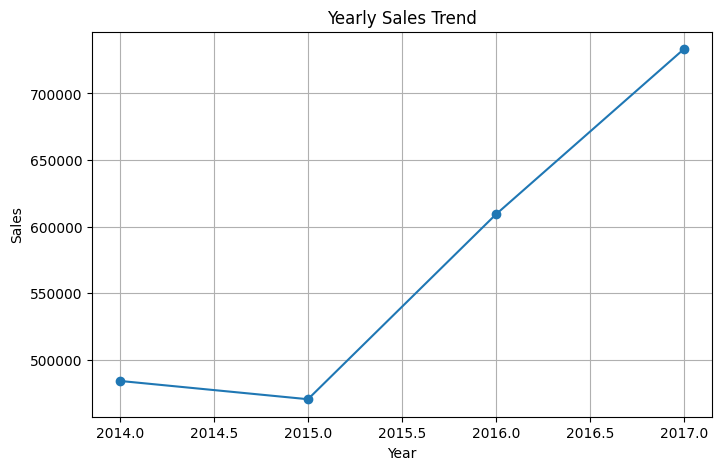

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_sales["order_year"],
    yearly_sales["sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

### Insight

Sales show an increasing trend over the years, indicating positive business growth and improved revenue generation.

## Monthly Sales Trend

Analyzing sales performance across different months.

In [13]:
monthly_sales = (
    df.groupby("order_month")["sales"]
    .sum()
    .reset_index()
)

monthly_sales

,order_month,sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


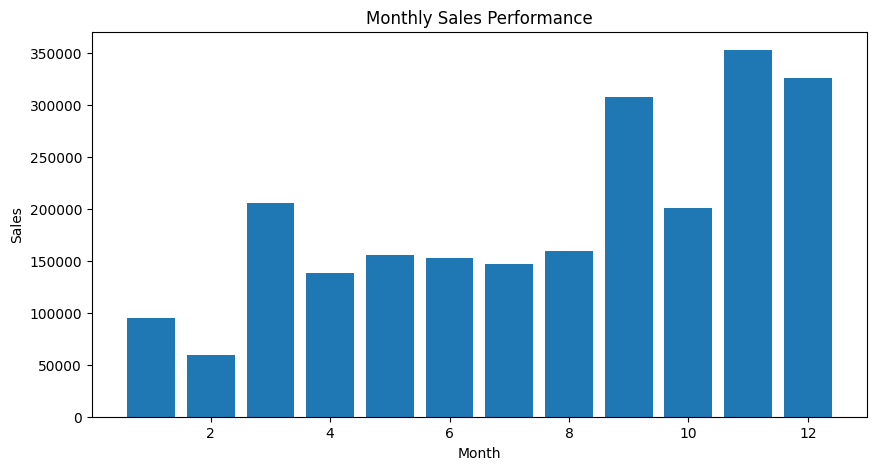

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_sales["order_month"],
    monthly_sales["sales"]
)

plt.title("Monthly Sales Performance")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [16]:
#Best Sales Month
best_month = monthly_sales.sort_values(
    by="sales",
    ascending=False
)

best_month.head()

,order_month,sales
10,11,352461.0710
11,12,325293.5035
8,9,307649.9457
2,3,205005.4888
9,10,200322.9847


### Business Insight

The highest-performing months contribute significantly to yearly revenue. 
These periods can be targeted for marketing campaigns and inventory planning.

# 3. Profitability Analysis

Analyzing company profitability to identify:

- Overall profit performance
- High-profit product categories
- Loss-making areas
- Impact of discounts on profitability

## Profit by Product Category

Analyzing which product categories contribute most to business profit.

In [17]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_profit

,category,profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


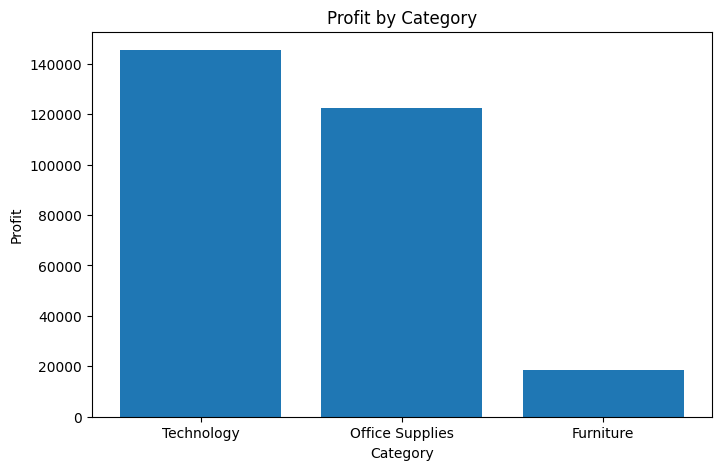

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    category_profit["category"],
    category_profit["profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

### Insight

Technology generated the highest profit, while Furniture showed significantly lower profitability compared with other categories.

## Profit by Sub-Category

Finding best and worst performing product groups.

In [19]:
subcategory_profit = (
    df.groupby("sub_category")["profit"]
    .sum()
    .sort_values()
    .reset_index()
)

subcategory_profit

,sub_category,profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995
3,Fasteners,949.5182
4,Machines,3384.7569
5,Labels,5546.2540
6,Art,6527.7870
7,Envelopes,6964.1767
8,Furnishings,13059.1436
9,Appliances,18138.0054


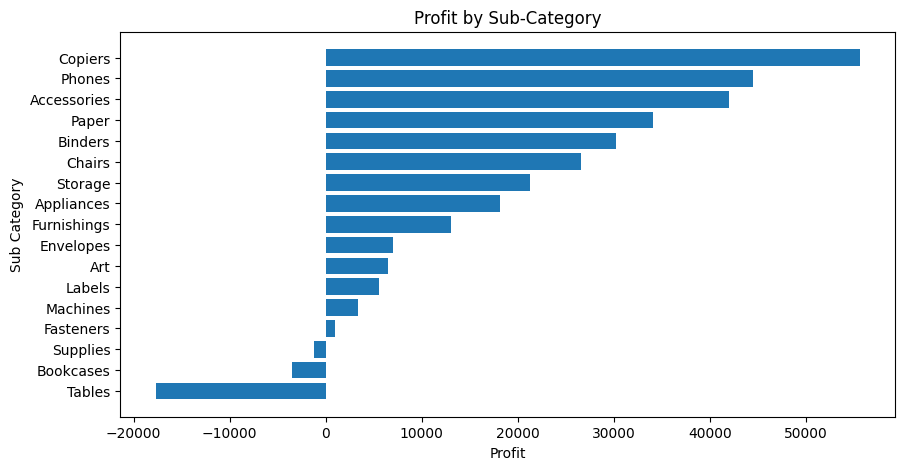

In [20]:
plt.figure(figsize=(10,5))

plt.barh(
    subcategory_profit["sub_category"],
    subcategory_profit["profit"]
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub Category")
plt.show()

## Loss Making Transactions

Identifying transactions where company generated negative profit.

In [21]:
loss_orders = df[df["profit"] < 0]

loss_orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,year,month,order_year,order_month,shipping_days
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015,10,7
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580,2015,11,2015,11,4
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160,2015,11,2015,11,4
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196,2017,7,2017,7,2
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522,2015,9,2015,9,4


In [22]:
loss_orders.shape

(1871, 26)

In [23]:
total_loss = loss_orders["profit"].sum()

print(f"Total Loss: ${total_loss:,.2f}")

Total Loss: $-156,131.29


In [ ]:
## Discount vs Profit Analysis

Analyzing whether high discounts are affecting profitability.

In [24]:
discount_analysis = (
    df.groupby("discount")["profit"]
    .mean()
    .reset_index()
)

discount_analysis

,discount,profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


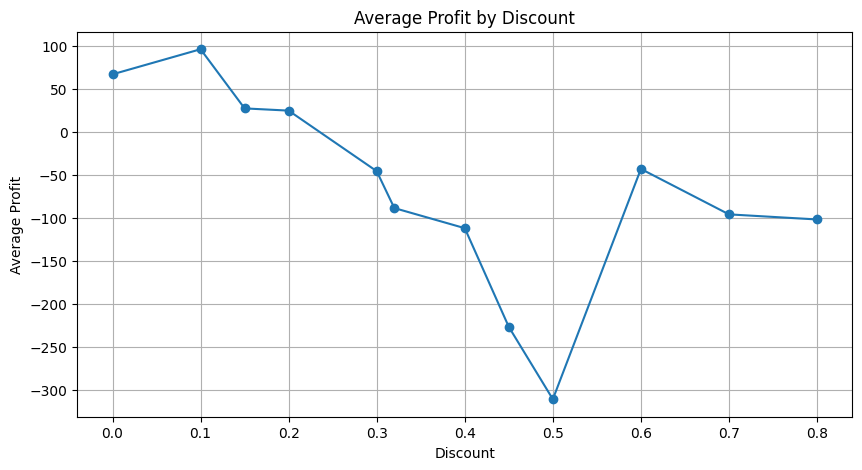

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    discount_analysis["discount"],
    discount_analysis["profit"],
    marker="o"
)

plt.title("Average Profit by Discount")

plt.xlabel("Discount")

plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

### Business Insight

Higher discount levels are associated with reduced profitability. 
Excessive discounting should be reviewed to prevent margin loss.